### Testing DC2 model on DP1 data

In [91]:
import detectron2
from detectron2.utils.logger import setup_logger

setup_logger()

import numpy as np
import os, json, cv2, random

import matplotlib.pyplot as plt

# import some common detectron2 utilities
from detectron2 import model_zoo
from detectron2.engine import DefaultPredictor
from detectron2.config import LazyConfig
from detectron2.utils.visualizer import Visualizer
from detectron2.data import MetadataCatalog, DatasetCatalog
from detectron2.data import build_detection_train_loader
from detectron2.engine import DefaultTrainer
from detectron2.engine import SimpleTrainer
from detectron2.engine import HookBase
from typing import Dict, List, Optional
import detectron2.solver as solver
import detectron2.modeling as modeler
import detectron2.data as data
import detectron2.data.transforms as T
import detectron2.checkpoint as checkpointer
from detectron2.data import detection_utils as utils
import weakref
import copy
import torch
import time

import deepdisc.astrodet.astrodet as toolkit
from deepdisc.astrodet import detectron as detectron_addons

from deepdisc.data_format.file_io import DDLoader
from deepdisc.data_format.annotation_functions.annotate_hsc import annotate_hsc
from astropy.visualization import make_lupton_rgb


In [34]:
# Initialize a DDLoader class, which will just be used to load existing files
json_loader = DDLoader()

#change filepath to where you have the data
filepath = '/work/hdd/bdsp/g4merz/DP1/processed_data/test_dicts_new.json'

test_dicts = json_loader.load_coco_json_file(filepath).get_dataset()
    
    
# Lets you rerun this cell without raising an error
if f"astro_test" in DatasetCatalog.list():
    DatasetCatalog.remove(f"astro_test")
    MetadataCatalog.remove("astro_test")

DatasetCatalog.register(f"astro_test", lambda: json_loader.load_coco_json_file(filepath).get_dataset())
MetadataCatalog.get(f"astro_test").set(thing_classes=["galaxy","star"])

astrotest_metadata = MetadataCatalog.get(f"astro_test")


In [188]:
#Setting up the data loading, you will have to change the filepath to the directory holding the images
from deepdisc.data_format.image_readers import NumpyImageReader
reader = NumpyImageReader()
def key_mapper(d):
    imgind = int(d['filename'].split('/')[-1].split('.npy')[0][4:])
    filename = f"test_v4_cutouts_{imgind}.npy"
    dirpath = "/work/hdd/bdsp/g4merz/DP1/processed_data/"
    key = os.path.join(dirpath, filename)
    return key


### Inference

Using an older model, so need to use a config file that points to slightly older code 

In [96]:
from deepdisc.inference.predictors import AstroPredictor

#change filepaths
output_dir = '/work/hdd/bdsp/g4merz/DC2/model_tests/'

cfgfile = 'configs/solo/solo_mvitv2_DC2_gold_classes_ebv_gals_est.py'
cfg = LazyConfig.load(cfgfile)
cfg.OUTPUT_DIR = output_dir
cfg.train.init_checkpoint = os.path.join(cfg.OUTPUT_DIR, "MViTv2_NG5_nlim_classes_ebv_gals.pth")

#setting to CPU just for testing inference 
cfg.train.device='cpu'


#play with detection sensitivity
#for box_predictor in cfg.model.roi_heads.box_predictors:
#    box_predictor.test_score_thresh = 0.5
#    box_predictor.test_nms_thresh = 0.3


predictor = AstroPredictor(cfg)



[10/09 16:28:34 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from /work/hdd/bdsp/g4merz/DC2/model_tests/MViTv2_NG5_nlim_classes_ebv_gals.pth ...


In [93]:
def get_outputs_withwcs(predictor, d, image):
    '''
    Function that processes data and feeds it to the model to produce predictions.
    Includes WCS info. 
    
    inputs
        predictor: AstroPredictor
            Predictor that holds a trained model
        d: dict
            Dataset dictionary containing WCS info
        image: ndarray
            image with shape HeightxWidthxChannels
            
    outputs
        out: Instances
            Predicted instances containing object classes, redshift PDFs, etc
    
    '''
    wcs = d['wcs']
    image = np.transpose(image,axes=(2,0,1))
    with torch.no_grad():  
        image = torch.as_tensor(image.astype("float32"))
        inputs = {'image':image, 'wcs':wcs, 'height':image.shape[1], 'width':image.shape[2]}

        out = predictor.model([inputs])

    return out


def get_outputs_withwcs_forced(predictor, d, image):
    '''
    Function that processes data and feeds it to the model to produce predictions.  
    Uses forced photometry, i.e., all object locations are fixed based on the input annotations.  
    Includes WCS info.
    
    inputs
        predictor: AstroPredictor
            Predictor that holds a trained model
        d: dict
            Dataset dictionary containing WCS info
        image: ndarray
            image with shape HeightxWidthxChannels
            
    outputs
        out: Instances
            Predicted instances containing object classes, redshift PDFs, etc
    
    '''
    
    wcs = d['wcs']
    imgind = int(d['filename'].split('/')[-1].split('.npy')[0][4:])
    image = np.transpose(image,axes=(2,0,1))

    instances = utils.annotations_to_instances(d['annotations'], image.shape[1:])
    instances.pred_boxes = instances.gt_boxes
    instances.pred_classes = instances.gt_classes
    instances.gt_id = torch.tensor([a["objectId"] for a in d['annotations']])
    instances.gt_redshift = torch.tensor([a["redshift"] for a in d['annotations']])
    
    with torch.no_grad():  
        image = torch.as_tensor(image.astype("float32"))
        inputs = {'image':image, 'wcs':wcs, 'height':image.shape[1], 'width':image.shape[2], 'annotations':d['annotations'], 'img_index':imgind}
        out = predictor.model.inference([inputs],[instances])


    return out



total instances: 6
detected instances: 6



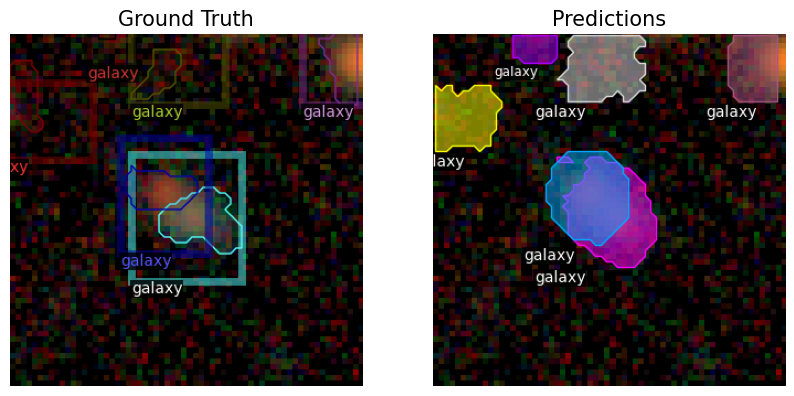

In [87]:
from detectron2.utils.visualizer import ColorMode
from deepdisc.astrodet.visualizer import Visualizer


nsample = 1
fig = plt.figure(figsize=(10, 5 * nsample))

for i, d in enumerate(random.sample(test_dicts, nsample)):
    img = reader(key_mapper(d))
    
    imgv = make_lupton_rgb(img[:,:,3],img[:,:,2],img[:,:,1],stretch=15,Q=10)
    
    print("total instances:", len(d["annotations"]))
    v0 = Visualizer(
        imgv,
        metadata=astrotest_metadata,
        scale=5,
        instance_mode=ColorMode.SEGMENTATION,
    )
    groundTruth = v0.draw_dataset_dict(d,alpha=0.1,boxf=True)

    ax1 = plt.subplot(nsample, 2, 2 * i + 1)
    ax1.imshow(groundTruth.get_image())
    ax1.axis("off")
    ax1.set_title('Ground Truth',fontsize=15)


    v1 = Visualizer(
        imgv,
        metadata=astrotest_metadata,
        scale=5,
        instance_mode=ColorMode.SEGMENTATION,
    )
    outputs = get_outputs_withwcs_fixed(predictor,d,img)[0]
    out = v1.draw_instance_predictions(outputs["instances"].to("cpu"))
    print("detected instances:", len(outputs["instances"].pred_boxes))
    print("")
    ax1 = plt.subplot(nsample, 2, 2 * i + 2)
    ax1.imshow(out.get_image())
    ax1.axis("off")
    ax1.set_title('Predictions',fontsize=15)

In [88]:
outputs['instances'].get_fields().keys()


dict_keys(['gt_boxes', 'gt_classes', 'gt_masks', 'pred_boxes', 'pred_classes', 'gt_id', 'gt_redshift', 'pred_masks', 'pred_redshift_pdf', 'pred_gmm'])

The predicted photo-zs are stored as gaussian mixture models, where a tensor represents the weights, means and (log) standard deviations of each gaussian.  Our config defines the num_components=5, so there are 5 total gaussians.  We can plot the PDFs by defining a grid.

In [89]:
#convert the predicted gmms to weights, means and standard deviations
import torch.nn.functional as F

gmm = outputs['instances'].pred_gmm.cpu()
ws = gmm[..., :5]
ws = F.softmax(ws, dim=-1).numpy()
mus = gmm[..., 5:10]
stds = torch.exp(gmm[..., 10:])


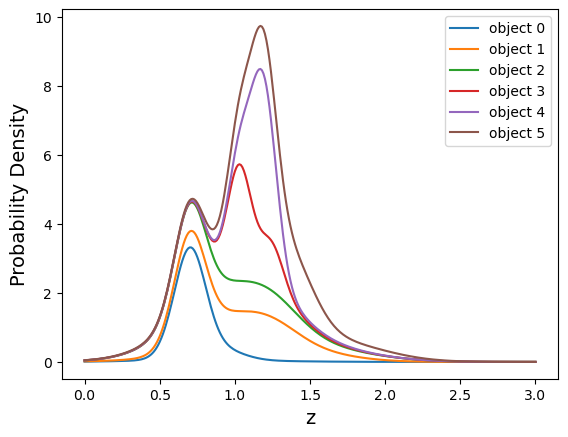

In [90]:
import scipy.stats as stats

xs = np.linspace(0, 3, 301)
ys = np.zeros_like(xs)

for j in range(len(ws)):

    for i in range(5):
        ys += stats.norm.pdf(xs, loc=mus[j].squeeze()[i], scale=stds[j].squeeze()[i]) * ws[j].squeeze()[i]
    plt.plot(xs,ys,label=f'object {j}')

plt.xlabel('z',fontsize=14)
plt.ylabel('Probability Density',fontsize=14)

plt.legend(loc=0)